# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [6]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic data (replace with your project dataset)
np.random.seed(0)
n = 100
df = pd.DataFrame({
    'income': np.random.normal(60000, 15000, n).astype(int),
    'monthly_spend': np.random.normal(2000, 600, n).astype(int),
    'credit_score': np.random.normal(680, 50, n).astype(int),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'default_flag': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})
df.head()

,income,monthly_spend,credit_score,region,default_flag
0,86460,3129,661,East,0
1,66002,1191,668,North,0
2,74681,1237,734,West,0
3,93613,2581,712,South,1
4,88013,1296,712,East,1


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

In [8]:
# Worked example 1 of 3 — keep it, or swap in columns of your own.
df['spend_income_ratio'] = df['monthly_spend'] / df['income']
# Write the rationale in the markdown cell below.

This shows how much someone spends relative to what they earn. Two people could have
the same monthly spend but very different risk levels depending on their income . 


### Rationale for Feature 1
Explain why this feature may help a model. Reference your EDA.

In [9]:
df['log_income'] = np.log(df['income'])

### Rationale for Feature 2
Income usually has some really high values that pull the distribution to one side.
Taking the log makes it more balanced, which usually helps models work better.

In [10]:
df['region_freq'] = df['region'].map(df['region'].value_counts(normalize=True))

### Rationale for Feature 3
I picked frequency encoding over one-hot or label encoding. One-hot would make too
many extra columns, and label encoding gives each region a number that makes it look
like there's an order between them, which isn't true. Frequency encoding just uses
how common each region is, so it felt simpler and more accurate.

spend_income_ratio   -0.036101
log_income            0.127001
region_freq           0.033070
Name: default_flag, dtype: float64


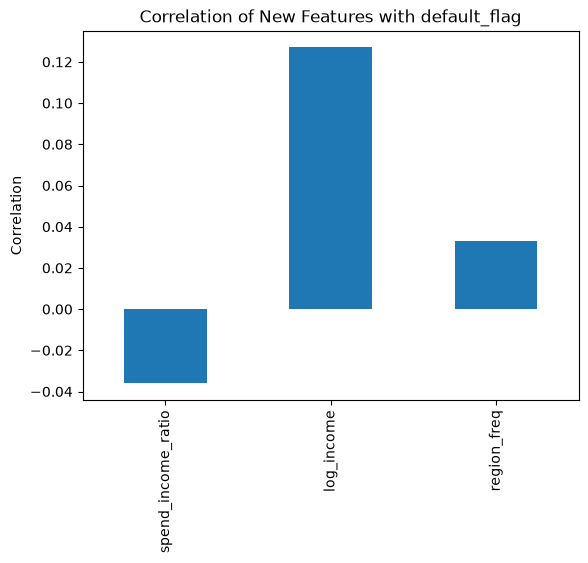

In [11]:
new_features = ['spend_income_ratio', 'log_income', 'region_freq']
corr_with_target = df[new_features + ['default_flag']].corr()['default_flag'].drop('default_flag')
print(corr_with_target)

import matplotlib.pyplot as plt
corr_with_target.plot(kind='bar')
plt.title('Correlation of New Features with default_flag')
plt.ylabel('Correlation')
plt.show()

## Correlation Check
None of the three features are really correlated with default_flag here, but that
makes sense since the target was just randomly generated in this fake dataset. On
real data I had expect spend_income_ratio to actually matter, since spending way more
than you earn is usually a bad sign.